# Семинар 1. Линейная регрессия

#### Шаг 1. Загрузка датасета и вывод на экран

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('delivery_dataset.csv', encoding='utf-8-sig')
print(df.head())
print(df.shape)
print(df.columns.tolist())

  Дата заказа (ГГГГ-ММ-ДД) Шифр заказа (ID)  Расстояние до клиента (в км)  \
0               2026-09-08    ORD-202608001                          11.3   
1               2026-08-29    ORD-202608002                           7.3   
2               2026-08-15    ORD-202608003                           2.2   
3               2026-08-08    ORD-202608004                           0.9   
4               2026-08-21    ORD-202608005                          12.3   

   Количество позиций в чеке (в шт.)  Балл пробок на дорогах (в баллах)  \
0                                  1                                  9   
1                                  3                                  7   
2                                  1                                  3   
3                                  2                                  6   
4                                 14                                  4   

   Погода (в градусах Цельсия)  Этаж доставки (в этажах)  \
0                         

#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих; 
* в тестовой: 100 последних.

In [5]:
target_col = 'Время доставки (в минутах)'
feature_cols = [
    'Расстояние до клиента (в км)',
    'Количество позиций в чеке (в шт.)',
    'Балл пробок на дорогах (в баллах)',
    'Погода (в градусах Цельсия)',
    'Этаж доставки (в этажах)'
]

train = df.iloc[:300].copy()
val   = df.iloc[300:400].copy()
test  = df.iloc[400:500].copy()

X_train = train[feature_cols].values
y_train = train[target_col].values

X_val  = val[feature_cols].values
y_val  = val[target_col].values

X_test = test[feature_cols].values
y_test = test[target_col].values

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(300, 5) (300,)
(100, 5) (100,)
(100, 5) (100,)


#### Вопрос 1. 

Для чего мы разбиваем данные на выборки? Для чего нам нужна тренировачная, для чего валидационная, для чего тестовая?

Вопрос 1.
Тренировочная нужна, чтобы обучить модель и подобрать парамтеры. Модель подстраивает их, чтобы уменьшить ошибку.
Валидационная нужна, чтобы оценивать модель на данных, которые она не видела при обучении. Она используется для выбора гиперпараметров(например alpha в Ridge, число итераций), ранней остановки и контроля переобучения. Тестовая нужна для финальной независимой оценки. Если использовать ее при настройке модели, она перестает быть независимой: мы подгоняем модель чисто под тестовую, и итоговая оценка становится нереалистичной.

#### Шаг 3. Установка sklearn чтобы обучать модель линейной регрессии через Ridge

In [6]:
pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 8.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 5.8 MB/s eta 0:00:00a 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

In [7]:
from sklearn.linear_model import Ridge
model = Ridge(alpha=0.0, solver='sparse_cg', max_iter=1000, tol=1e-8)
model.fit(X_train, y_train)
print('Intercept (w0):', model.intercept_)
print('Коэффициенты:', model.coef_)

Intercept (w0): -2.9673282180037432
Коэффициенты: [ 4.39612671  0.83532692  2.15389382 -0.04734781  0.34323145]


#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

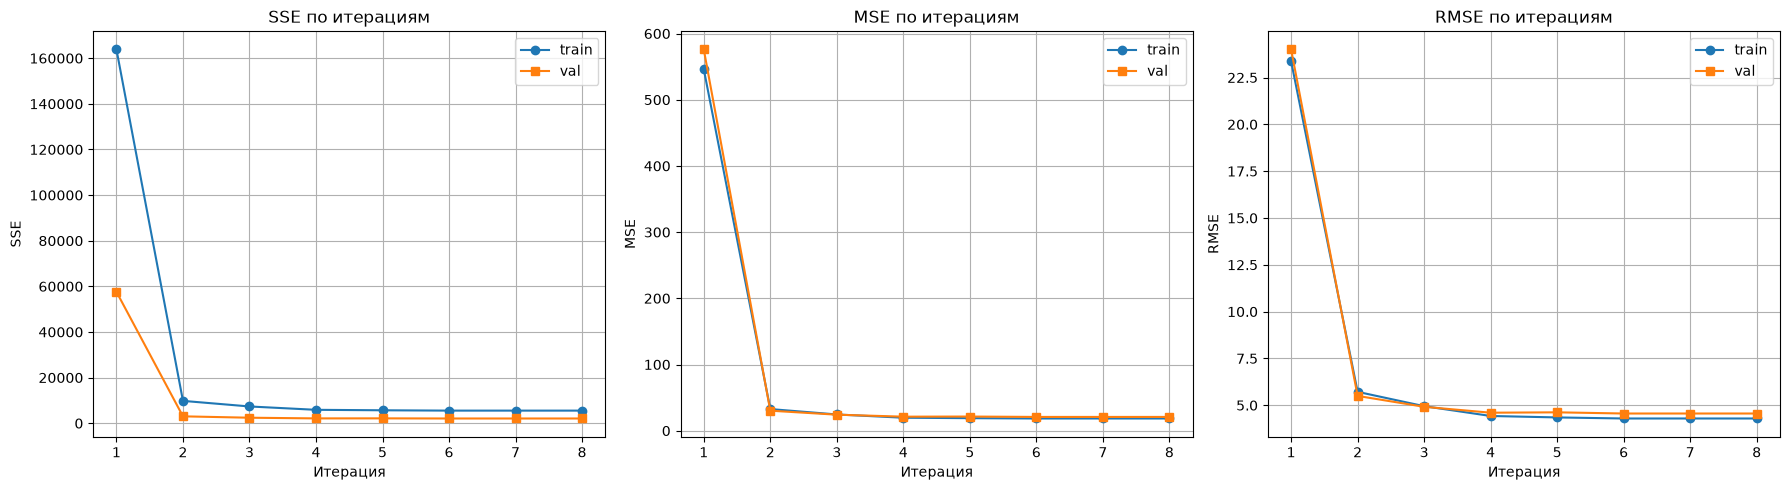

In [9]:
def sparse_cg_history(X, y, max_iter=50, tol=1e-10):
    m, n = X.shape
    X_aug = np.hstack([np.ones((m, 1)), X])
    A = X_aug.T @ X_aug
    b = X_aug.T @ y

    w = np.zeros(n + 1)
    r = b - A @ w
    p = r.copy()
    history = []

    for k in range(max_iter):
        Ap = A @ p
        denom = p @ Ap
        if abs(denom) < 1e-15:
            break

        alpha = (r @ r) / denom
        w = w + alpha * p
        r_new = r - alpha * Ap

        history.append(w.copy())

        if np.linalg.norm(r_new) < tol:
            break

        beta = (r_new @ r_new) / (r @ r)
        p = r_new + beta * p
        r = r_new

    return history

def compute_errors(w, X, y):
    m = X.shape[0]
    X_aug = np.hstack([np.ones((m, 1)), X])
    pred = X_aug @ w
    sse = np.sum((y - pred) ** 2)
    mse = sse / m
    rmse = np.sqrt(mse)
    return sse, mse, rmse

history = sparse_cg_history(X_train, y_train, max_iter=50, tol=1e-10)

train_sse, train_mse, train_rmse = [], [], []
val_sse,   val_mse,   val_rmse   = [], [], []

for w in history:
    sse, mse, rmse = compute_errors(w, X_train, y_train)
    train_sse.append(sse)
    train_mse.append(mse)
    train_rmse.append(rmse)

    sse, mse, rmse = compute_errors(w, X_val, y_val)
    val_sse.append(sse)
    val_mse.append(mse)
    val_rmse.append(rmse)

iters = np.arange(1, len(history) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(iters, train_sse, 'o-', label='train')
axes[0].plot(iters, val_sse, 's-', label='val')
axes[0].set_title('SSE по итерациям')
axes[0].set_xlabel('Итерация')
axes[0].set_ylabel('SSE')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(iters, train_mse, 'o-', label='train')
axes[1].plot(iters, val_mse, 's-', label='val')
axes[1].set_title('MSE по итерациям')
axes[1].set_xlabel('Итерация')
axes[1].set_ylabel('MSE')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(iters, train_rmse, 'o-', label='train')
axes[2].plot(iters, val_rmse, 's-', label='val')
axes[2].set_title('RMSE по итерациям')
axes[2].set_xlabel('Итерация')
axes[2].set_ylabel('RMSE')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

#### Вопрос 2.

Какую информацию про нашу модель несут эти графики?

1. Скорость сходимости. Показывают как быстро ошибка падает по итерациям.
2. Момент остановки. Когда кривая выходит на "прямую", а дальнейшие итерации не улучшают модель.
3. Переобучение - если ошибка на train продолжает падать, а val-ошибка перестала падать или наоборот растет, модель начала запоминать шум.
4. Недообучение. Если обе кривые стабилизировались на высоком уровне, модель слишком простая.
5. Согласованность. Близость train и val - если они примерно на одном уровне, модель обобщает хорошо.

У нас все хорошо на графиках, ошибки упали и остались на невысоком "плато".

#### Вопрос 3. 

Какая траектория линий train и val ошибок будет на графиках недообученной модели и почему?

Какая траектория линий train и val ошибок будет на графиках обученной модели и почему?

Какая траектория линий train и val ошибок будет на графиках переобученной модели и почему?

Недообученная модель: обе кривые высоко и почти горизонатльно (так как медленно убывают). Это потому что модель слишком простая - мало признаков, линейная зависимость не описывает данные, и она не может подстроиться ни под train ни под val.
Хорошо обученная модель: обе кривые быстро убывают и стабилизируются на низком уровне. Модель нашла закономерность, которая работает и на train и на val
Переобученная модель: train продолжает падать и падает до очень низкого уровня. Val сначала падает, затем перестает или начинает расти. Модель запоминает шум в train.

#### Шаг 6. Применение модели на тестовой выборке

In [10]:
y_test_pred = model.predict(X_test)

compare = pd.DataFrame({
    'y_true': y_test[:10],
    'y_pred': y_test_pred[:10]
})
print(compare)

   y_true     y_pred
0    33.9  33.066235
1    33.1  33.125508
2    16.3  20.852183
3    34.7  34.385205
4    13.3  17.562288
5    39.3  42.809253
6    36.3  37.448654
7    11.9  12.347193
8    56.5  59.054299
9    35.9  32.082636


#### Шаг 7. RMSE на тестовой выборке

In [11]:
rmse_test = np.sqrt(np.mean((y_test - y_test_pred) ** 2))
print(f'RMSE на тестовой выборке: {rmse_test:.3f} минут')

RMSE на тестовой выборке: 4.831 минут


#### Вопрос 4.

Что получившийся RMSE может сказать о нашей модели?

RMSE на тестовой выборке = 4.83 минуты. Это означает, что в среднем модель ошибается примерно на 4.8 минуты при предсказании времени доставки, причём крупные промахи штрафуются сильнее, чем мелкие.